# Medical Sound Classification — LSTM + Bidirectioneel LSTM

Dit notebook bouwt voort op de bestaande YAMNet pipeline en vervangt de gemiddelde embedding (`np.mean`) door een volledige tijdreeks die door een LSTM wordt verwerkt.

**Wat nieuw is t.o.v. het origineel:**
- `extract_embeddings_sequence()`: geeft de volledige tijdreeks terug (niet gemiddeld)
- Padding/truncatie naar een vaste `max_frames` lengte
- Drie modelvarianten: LSTM, Bidirectioneel LSTM, en 1D CNN (als baseline)
- Metadata combinatie via Functional API
- Vergelijking van de drie modellen

## 0. Imports

In [80]:
import os
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import scipy.signal
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, Model

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print("TensorFlow versie:", tf.__version__)
print("GPU beschikbaar:", tf.config.list_physical_devices('GPU'))

TensorFlow versie: 2.21.0
GPU beschikbaar: []


## 1. Data laden

In [81]:
df_train = pd.read_csv('data/train.csv')
df_test  = pd.read_csv('data/test.csv')

# Verwijder lege file
df_train = df_train.drop(df_train[df_train['candidateID'] == '5ee582f2832c2'].index)

# Missingness flag voor coldPresent
df_train['coldPresent_missing'] = df_train['coldPresent'].isna().astype(int)
df_train['coldPresent'] = df_train['coldPresent'].fillna(0)

print(f"Train samples: {len(df_train)}")
print(df_train['disease'].value_counts())

Train samples: 545
disease
1    238
2    167
0    140
Name: count, dtype: int64


## 2. YAMNet laden

In [82]:
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')
print("YAMNet geladen.")

YAMNet geladen.


## 3. Embedding extractie — tijdreeks (nieuw!)

Het verschil met het origineel: in plaats van `np.mean(embeddings, axis=0)` bewaren we alle tijdsframes.
YAMNet verwerkt audio in vensters van ~0.96s met een hop van ~0.48s.
Bij een segment van 2 seconden krijg je dus ±4 frames, bij een langere opname meer.

In [ ]:
def extract_embeddings_sequence(waveform):
    scores, embeddings, spectrogram = yamnet_model(waveform)
    return embeddings.numpy()


def extract_embeddings_mean(waveform):
    return np.mean(embeddings, axis=0)

TODO De extract embeddings mean wordt nooit gebruikt in deze code, wat raar is want het werd speciaal veranderd.

### 3.1 Bepaal een goede max_frames waarde

We samplen een paar bestanden om te zien hoeveel frames we typisch hebben.

In [84]:
# frame_counts = []

# for cid in df_train['candidateID'].head(20):
#     seg_folder = os.path.join("data/sounds/sounds", cid, "cough_segmented")
#     if not os.path.exists(seg_folder):
#         continue
#     for fname in os.listdir(seg_folder):
#         if fname.endswith("_processed.wav"):
#             fp = os.path.join(seg_folder, fname)
#             waveform, sr = librosa.load(fp, sr=16000)
#             waveform = waveform.astype(np.float32)
#             _, emb, _ = yamnet_model(waveform)
#             frame_counts.append(emb.shape[0])

# if frame_counts:
#     print(f"Frames — min: {min(frame_counts)}, max: {max(frame_counts)}, "
#           f"gemiddeld: {np.mean(frame_counts):.1f}, mediaan: {np.median(frame_counts):.0f}")
#     plt.hist(frame_counts, bins=20)
#     plt.xlabel('Aantal YAMNet frames per segment')
#     plt.ylabel('Frequentie')
#     plt.title('Verdeling van frames per audiosegment')
#     plt.axvline(np.percentile(frame_counts, 90), color='r', linestyle='--', label='90e percentiel')
#     plt.legend()
#     plt.show()
    
#     # Stel max_frames in op het 90e percentiel (dekt 90% van de data zonder te veel padding)
#     MAX_FRAMES = int(np.percentile(frame_counts, 90))
#     print(f"\nAanbevolen MAX_FRAMES: {MAX_FRAMES}")
# else:
#     MAX_FRAMES = 30
#     print(f"Geen segmented bestanden gevonden. MAX_FRAMES ingesteld op {MAX_FRAMES}")

In [85]:
# Pas hier aan als je een andere waarde wil testen
MAX_FRAMES = 4  # bijv. 20, 30, 50 ...
print(f"MAX_FRAMES = {MAX_FRAMES}")

MAX_FRAMES = 4


TODO Aangezien deze code redelijk ingewikkeld is kunnen we hier ook gewoon 4 nemen en zeggen dat we er een beetje mee hebben geprutst

## 4. Dataset bouwen

We bouwen twee datasets:
- `X_seq`: tijdreeks embeddings, shape `(samples, MAX_FRAMES, 1024)` → voor LSTM
- `X_meta`: metadata features, shape `(samples, n_meta)` → apart gecombineerd

Cough segmenten + vowel (indien beschikbaar), net als in het origineel.

TODO misschien nog namen veranderen

TODO iedere input is hier een aparte hoest of vowel.

In [ ]:
META_COLS = ['age', 'gender', 'tbContactHistory', 'wheezingHistory',
             'phlegmCough', 'familyAsthmaHistory', 'feverHistory',
             'coldPresent', 'packYears', 'coldPresent_missing']

df_filled = df_train.fillna(0)

X_seq  = []  # tijdreeks embeddings     TODO is X_emb een betere naam?
X_meta = []  # metadata
y_list = []  # labels

skipped = 0

for _, row in df_filled.iterrows():
    cid     = row['candidateID']
    disease = row['disease']
    meta    = row[META_COLS].values.astype(np.float32)
    
    # --- Cough segmenten ---
    seg_folder = os.path.join("data/sounds/sounds", cid, "cough_segmented")
    if os.path.exists(seg_folder):
        for fname in os.listdir(seg_folder):
            if fname.endswith("_processed.wav"):
                fp = os.path.join(seg_folder, fname)
                try:
                    waveform, sr = librosa.load(fp, sr=16000)
                    emb_seq = extract_embeddings_sequence(waveform)
                    X_seq.append(emb_seq)
                    X_meta.append(meta)
                    y_list.append(disease)
                except Exception as e:
                    print(f"Fout bij {fp}: {e}")
                    skipped += 1
    
    # --- Vowel ---
    vowel_path = os.path.join("data/sounds/sounds", cid, "vowel_processed.wav")
    if os.path.isfile(vowel_path):
        try:
            waveform, sr = librosa.load(vowel_path, sr=16000)
            emb_seq = extract_embeddings_sequence(waveform)
            X_seq.append(emb_seq)
            X_meta.append(meta)
            y_list.append(disease)
        except Exception as e:
            print(f"Fout bij {vowel_path}: {e}")
            skipped += 1

X_seq  = np.array(X_seq,  dtype=np.float32)   # (samples, MAX_FRAMES, 1024)
X_meta = np.array(X_meta, dtype=np.float32)   # (samples, n_meta)
y_arr  = np.array(y_list)

print(f"X_seq shape : {X_seq.shape}")
print(f"X_meta shape: {X_meta.shape}")
print(f"Labels shape: {y_arr.shape}")
print(f"Overgeslagen : {skipped}")

X_seq shape : (8858, 4, 1024)
X_meta shape: (8858, 10)
Labels shape: (8858,)
Overgeslagen : 0


In [ ]:
# Metadata schalen
scaler = StandardScaler()
X_meta_scaled = scaler.fit_transform(X_meta)

# Labels encoderen
# TODO volgens mij is dit al automatisch gedaan, test een keer zonder dit.
le = LabelEncoder()
y_encoded = le.fit_transform(y_arr)
num_classes = len(le.classes_)
print(f"Klassen: {le.classes_}  ({num_classes} klassen)")

# Train/val split — gestratificeerd
splits = train_test_split(
    X_seq,
    X_meta_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_seq_train, X_seq_val, X_meta_train, X_meta_val, y_train, y_val = splits

y_train_oh = to_categorical(y_train, num_classes)
y_val_oh   = to_categorical(y_val,   num_classes)

print(f"Training  : {len(X_seq_train)} samples")
print(f"Validatie : {len(X_seq_val)} samples")

Klassen: [0 1 2]  (3 klassen)
Training  : 7086 samples
Validatie : 1772 samples


## 5. Modellen

We bouwen drie varianten en vergelijken ze:

| Model | Beschrijving |
|-------|--------------|
| **LSTM** | Unidirectionele LSTM over tijdreeks + metadata |
| **BiLSTM** | Bidirectionele LSTM (kijkt ook achteruit) + metadata |
| **1D CNN** | Convoluties over de tijdas (sneller, stabiel bij kleine data) + metadata |

In [88]:
def build_lstm(max_frames, n_meta, num_classes, bidirectional=False):
    """
    Functional API model: tijdreeks (LSTM) + metadata gecombineerd.
    """
    # --- Audio tak ---
    audio_input = layers.Input(shape=(max_frames, 1024), name='audio_seq')
    
    lstm_layer = layers.LSTM(128, return_sequences=True)(audio_input)
    lstm_layer = layers.Dropout(0.3)(lstm_layer)
    lstm_layer = layers.LSTM(64)(lstm_layer)
    lstm_layer = layers.Dropout(0.3)(lstm_layer)
    
    if bidirectional:
        audio_input = layers.Input(shape=(max_frames, 1024), name='audio_seq')
        lstm_layer = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(audio_input)
        lstm_layer = layers.Dropout(0.3)(lstm_layer)
        lstm_layer = layers.Bidirectional(layers.LSTM(64))(lstm_layer)
        lstm_layer = layers.Dropout(0.3)(lstm_layer)
    
    # --- Metadata tak ---
    meta_input = layers.Input(shape=(n_meta,), name='metadata')
    meta_dense = layers.Dense(32, activation='relu')(meta_input)
    meta_dense = layers.Dropout(0.2)(meta_dense)
    
    # --- Combineer ---
    combined = layers.concatenate([lstm_layer, meta_dense])
    out = layers.Dense(64, activation='relu')(combined)
    out = layers.Dropout(0.3)(out)
    out = layers.Dense(num_classes, activation='softmax')(out)
    
    model = Model(inputs=[audio_input, meta_input], outputs=out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_1d_cnn(max_frames, n_meta, num_classes):
    """
    1D CNN over de tijdreeks van embeddings — vaak stabieler bij kleine datasets.
    """
    # --- Audio tak ---
    audio_input = layers.Input(shape=(max_frames, 1024), name='audio_seq')
    
    x = layers.Conv1D(128, kernel_size=3, activation='relu', padding='same')(audio_input)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(64, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.4)(x)
    
    # --- Metadata tak ---
    meta_input = layers.Input(shape=(n_meta,), name='metadata')
    meta_dense = layers.Dense(32, activation='relu')(meta_input)
    meta_dense = layers.Dropout(0.2)(meta_dense)
    
    # --- Combineer ---
    combined = layers.concatenate([x, meta_dense])
    out = layers.Dense(64, activation='relu')(combined)
    out = layers.Dropout(0.3)(out)
    out = layers.Dense(num_classes, activation='softmax')(out)
    
    model = Model(inputs=[audio_input, meta_input], outputs=out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


n_meta = X_meta_scaled.shape[1]
print(f"n_meta features: {n_meta}")

n_meta features: 10


## 6. Training

We trainen de drie modellen na elkaar en slaan de resultaten op voor vergelijking.

In [89]:
def train_model(model, name, epochs=60, batch_size=16):
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print(f"{'='*50}")
    model.summary()
    
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
    
    history = model.fit(
        [X_seq_train, X_meta_train], y_train_oh,
        validation_data=([X_seq_val, X_meta_val], y_val_oh),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1
    )
    
    val_loss, val_acc = model.evaluate([X_seq_val, X_meta_val], y_val_oh, verbose=0)
    y_pred = np.argmax(model.predict([X_seq_val, X_meta_val], verbose=0), axis=1)
    macro_f1 = f1_score(y_val, y_pred, average='macro')
    
    print(f"\n{name} — Val Accuracy: {val_acc:.4f} | Macro F1: {macro_f1:.4f}")
    print(classification_report(y_val, y_pred, target_names=le.classes_.astype(str)))
    
    return history, val_acc, macro_f1, y_pred

In [90]:
# --- LSTM ---
lstm_model = build_lstm(MAX_FRAMES, n_meta, num_classes, bidirectional=False)
hist_lstm, acc_lstm, f1_lstm, pred_lstm = train_model(lstm_model, "LSTM")


Training: LSTM


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ audio_seq           │ (None, 4, 1024)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_24 (LSTM)      │ (None, 4, 128)    │    590,336 │ audio_seq[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_52          │ (None, 4, 128)    │          0 │ lstm_24[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata            │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_25 (LSTM)      │ (None, 64)        │     49,408 │ dropout_52[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 32)        │        352 │ metadata[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_53          │ (None, 64)        │          0 │ lstm_25[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_54          │ (None, 32)        │          0 │ dense_36[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_12      │ (None, 96)        │          0 │ dropout_53[0][0], │
│ (Concatenate)       │                   │            │ dropout_54[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_37 (Dense)    │ (None, 64)        │      6,208 │ concatenate_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_55          │ (None, 64)        │          0 │ dense_37[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_38 (Dense)    │ (None, 3)         │        195 │ dropout_55[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 646,499 (2.47 MB)

 Trainable params: 646,499 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7446 - loss: 0.6190 - val_accuracy: 0.8290 - val_loss: 0.4202
Epoch 2/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8240 - loss: 0.4651 - val_accuracy: 0.8561 - val_loss: 0.3818
Epoch 3/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8339 - loss: 0.4296 - val_accuracy: 0.8448 - val_loss: 0.3633
Epoch 4/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8425 - loss: 0.4077 - val_accuracy: 0.8629 - val_loss: 0.3545
Epoch 5/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8465 - loss: 0.3955 - val_accuracy: 0.8623 - val_loss: 0.3419
Epoch 6/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8511 - loss: 0.3797 - val_accuracy: 0.8640 - val_loss: 0.3351
Epoch 7/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8582 - loss: 0.3697 - val_accuracy: 0.8674 - val_loss: 0.3314
Epoch 8/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8634 - loss: 0.3527 - val_accuracy: 0.

In [91]:
# --- Bidirectioneel LSTM ---
bilstm_model = build_lstm(MAX_FRAMES, n_meta, num_classes, bidirectional=True)
hist_bilstm, acc_bilstm, f1_bilstm, pred_bilstm = train_model(bilstm_model, "BiLSTM")


Training: BiLSTM


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ audio_seq           │ (None, 4, 1024)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_8     │ (None, 4, 256)    │  1,180,672 │ audio_seq[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_58          │ (None, 4, 256)    │          0 │ bidirectional_8[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata            │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_9     │ (None, 128)       │    164,352 │ dropout_58[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_39 (Dense)    │ (None, 32)        │        352 │ metadata[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_59          │ (None, 128)       │          0 │ bidirectional_9[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_60          │ (None, 32)        │          0 │ dense_39[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_13      │ (None, 160)       │          0 │ dropout_59[0][0], │
│ (Concatenate)       │                   │            │ dropout_60[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_40 (Dense)    │ (None, 64)        │     10,304 │ concatenate_13[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_61          │ (None, 64)        │          0 │ dense_40[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_41 (Dense)    │ (None, 3)         │        195 │ dropout_61[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,355,875 (5.17 MB)

 Trainable params: 1,355,875 (5.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.7254 - loss: 0.6555 - val_accuracy: 0.8239 - val_loss: 0.4841
Epoch 2/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8112 - loss: 0.4890 - val_accuracy: 0.8426 - val_loss: 0.4042
Epoch 3/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8316 - loss: 0.4472 - val_accuracy: 0.8437 - val_loss: 0.3742
Epoch 4/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8411 - loss: 0.4124 - val_accuracy: 0.8516 - val_loss: 0.3582
Epoch 5/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8487 - loss: 0.3907 - val_accuracy: 0.8719 - val_loss: 0.3380
Epoch 6/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8510 - loss: 0.3722 - val_accuracy: 0.8578 - val_loss: 0.3365
Epoch 7/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8594 - loss: 0.3521 - val_accuracy: 0.8657 - val_loss: 0.3184
Epoch 8/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8689 - loss: 0.3416 - val_accuracy

In [92]:
# --- 1D CNN ---
cnn_model = build_1d_cnn(MAX_FRAMES, n_meta, num_classes)
hist_cnn, acc_cnn, f1_cnn, pred_cnn = train_model(cnn_model, "1D CNN")


Training: 1D CNN


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ audio_seq           │ (None, 4, 1024)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 4, 128)    │    393,344 │ audio_seq[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 128)    │        512 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 2, 128)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 2, 64)     │     24,640 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2, 64)     │        256 │ conv1d_9[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata            │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_42 (Dense)    │ (None, 32)        │        352 │ metadata[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_62          │ (None, 64)        │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_63          │ (None, 32)        │          0 │ dense_42[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_14      │ (None, 96)        │          0 │ dropout_62[0][0], │
│ (Concatenate)       │                   │            │ dropout_63[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_43 (Dense)    │ (None, 64)        │      6,208 │ concatenate_14[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_64          │ (None, 64)        │          0 │ dense_43[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_44 (Dense)    │ (None, 3)         │        195 │ dropout_64[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 425,507 (1.62 MB)

 Trainable params: 425,123 (1.62 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7034 - loss: 0.7044 - val_accuracy: 0.8222 - val_loss: 0.4592
Epoch 2/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8044 - loss: 0.5016 - val_accuracy: 0.8347 - val_loss: 0.4100
Epoch 3/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8205 - loss: 0.4695 - val_accuracy: 0.8442 - val_loss: 0.3887
Epoch 4/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8254 - loss: 0.4469 - val_accuracy: 0.8482 - val_loss: 0.3800
Epoch 5/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8377 - loss: 0.4226 - val_accuracy: 0.8606 - val_loss: 0.3656
Epoch 6/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8436 - loss: 0.4080 - val_accuracy: 0.8606 - val_loss: 0.3518
Epoch 7/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8470 - loss: 0.3941 - val_accuracy: 0.8657 - val_loss: 0.3552
Epoch 8/60
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8483 - loss: 0.3918 - val_accuracy: 0.

## 7. Vergelijking

 Model  Val Accuracy  Macro F1
  LSTM      0.882618  0.881100
BiLSTM      0.882054  0.878496
1D CNN      0.892212  0.887803


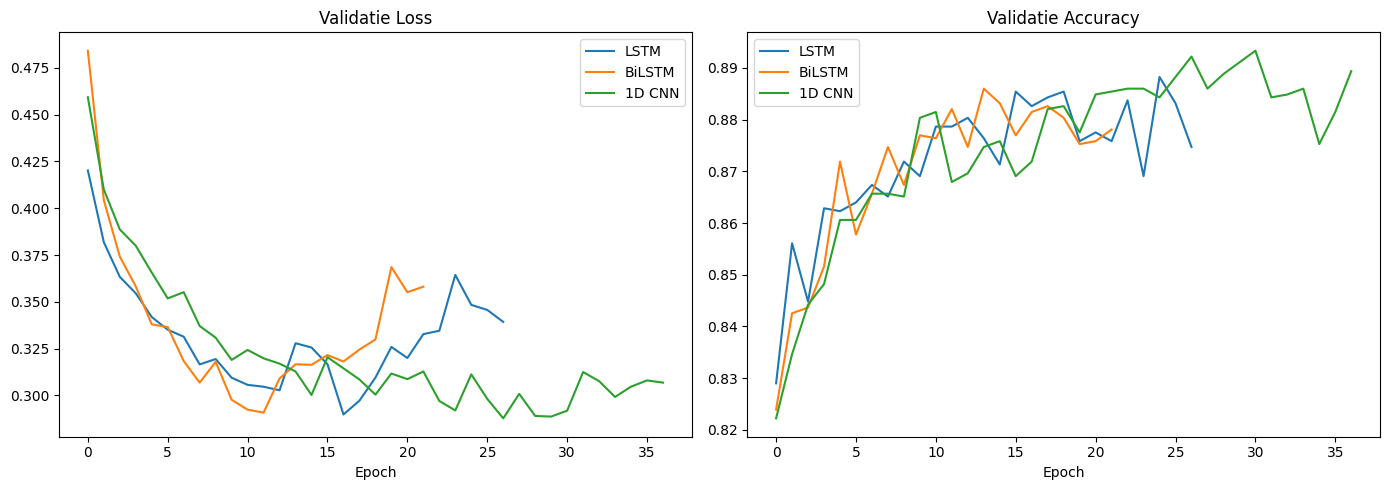

In [93]:
results = pd.DataFrame({
    'Model'      : ['LSTM', 'BiLSTM', '1D CNN'],
    'Val Accuracy': [acc_lstm, acc_bilstm, acc_cnn],
    'Macro F1'   : [f1_lstm,  f1_bilstm,  f1_cnn]
})
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for hist, name in [(hist_lstm, 'LSTM'), (hist_bilstm, 'BiLSTM'), (hist_cnn, '1D CNN')]:
    axes[0].plot(hist.history['val_loss'], label=name)
    axes[1].plot(hist.history['val_accuracy'], label=name)

axes[0].set_title('Validatie Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].set_title('Validatie Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

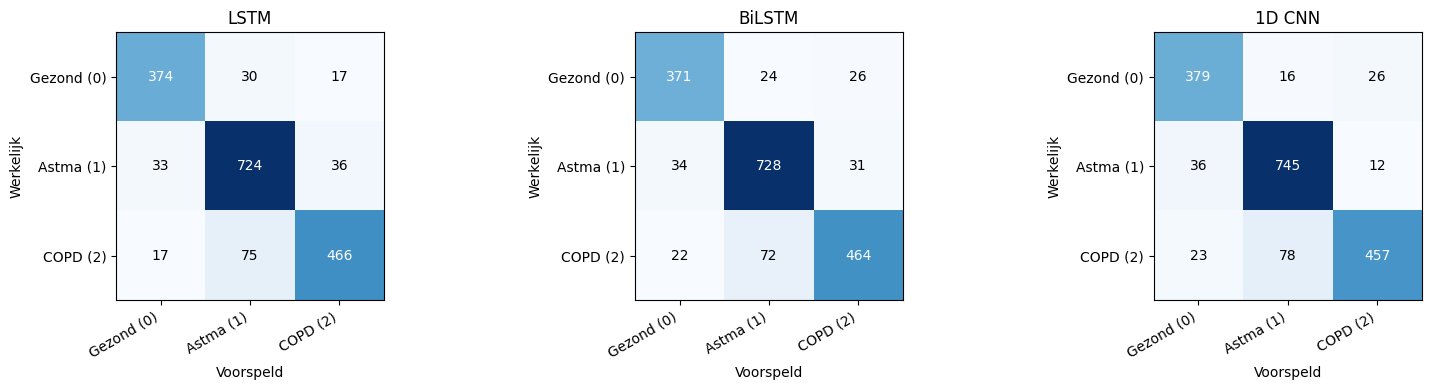

In [94]:
# Confusion matrices naast elkaar
class_names = ['Gezond (0)', 'Astma (1)', 'COPD (2)']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, preds, name in [
    (axes[0], pred_lstm,   'LSTM'),
    (axes[1], pred_bilstm, 'BiLSTM'),
    (axes[2], pred_cnn,    '1D CNN')
]:
    cm = confusion_matrix(y_val, preds)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(name)
    ax.set_xticks(range(num_classes))
    ax.set_yticks(range(num_classes))
    ax.set_xticklabels(class_names, rotation=30, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Voorspeld')
    ax.set_ylabel('Werkelijk')
    for i in range(num_classes):
        for j in range(num_classes):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

## 8. Beste model opslaan

In [95]:
# import joblib

best_f1 = max(f1_lstm, f1_bilstm, f1_cnn)
best_name = ['LSTM', 'BiLSTM', '1D CNN'][[f1_lstm, f1_bilstm, f1_cnn].index(best_f1)]
best_model = {'LSTM': lstm_model, 'BiLSTM': bilstm_model, '1D CNN': cnn_model}[best_name]

print(f"Beste model: {best_name} (Macro F1 = {best_f1:.4f})")

# best_model.save(f"best_model_{best_name.replace(' ', '_').lower()}.keras")
# joblib.dump(scaler, "scaler_lstm_experiment.pkl")
# joblib.dump(le,     "label_encoder_lstm_experiment.pkl")

# print("Model, scaler en label encoder opgeslagen.")

Beste model: 1D CNN (Macro F1 = 0.8878)


## 9. Inferentie op testset (optioneel)

Pas dit aan naar de structuur van jouw test CSV.

In [96]:
# Uncomment en pas aan zodra je de testset wil evalueren

# df_test_filled = df_test.fillna(0)
# if 'coldPresent_missing' not in df_test_filled.columns:
#     df_test_filled['coldPresent_missing'] = df_test['coldPresent'].isna().astype(int)

# X_seq_test  = []
# X_meta_test = []
# test_ids    = []

# for _, row in df_test_filled.iterrows():
#     cid  = row['candidateID']
#     meta = row[META_COLS].values.astype(np.float32)
#
#     seg_folder = os.path.join("data/sounds/sounds", cid, "cough_segmented")
#     if os.path.exists(seg_folder):
#         for fname in os.listdir(seg_folder):
#             if fname.endswith("_processed.wav"):
#                 fp = os.path.join(seg_folder, fname)
#                 waveform, _ = librosa.load(fp, sr=16000)
#                 emb_seq = extract_embeddings_sequence(waveform, MAX_FRAMES)
#                 X_seq_test.append(emb_seq)
#                 X_meta_test.append(meta)
#                 test_ids.append(cid)

# X_seq_test  = np.array(X_seq_test,  dtype=np.float32)
# X_meta_test = scaler.transform(np.array(X_meta_test, dtype=np.float32))

# y_pred_test = np.argmax(best_model.predict([X_seq_test, X_meta_test]), axis=1)
# y_pred_labels = le.inverse_transform(y_pred_test)

# submission = pd.DataFrame({'candidateID': test_ids, 'disease': y_pred_labels})
# # Aggregeer per kandidaat (meerdere segmenten → majority vote)
# submission = submission.groupby('candidateID')['disease'].agg(lambda x: x.mode()[0]).reset_index()
# submission.to_csv('submission_lstm.csv', index=False)
# print(submission.head())

print("Testset inferentie klaar om te gebruiken — uncomment de code hierboven.")

Testset inferentie klaar om te gebruiken — uncomment de code hierboven.
